# LULC

#### Workflow summary

- Imports & initialization – Earth Engine Python API
- Load AOI, ESA 2021 labels, and AlphaEarth embeddings
- Tile-based sampling to create memory-efficient training points
- Train Random Forest classifier fully in GEE
- Evaluate classifier using confusion matrix on training points
- Classify embeddings for 2021–2024
- Export all LULC maps directly to Google Drive

# Setup and imports

In [65]:
# -------------------------------
# 1️⃣ Imports and initialization
# -------------------------------
import ee
import numpy as np
import leafmap.maplibregl as leafmap
import pandas as pd
import matplotlib.pyplot as plt

# Define AOI and load data

In [38]:
ee.Authenticate()
ee.Initialize(project="alphaearth-476700")

In [ ]:
# -------------------------------
# 2️⃣ Parameters
# -------------------------------
roi = ee.Geometry.Rectangle([8, 44.5, 11.0, 46])  # approx: area in Northern Italy
lon_steps = np.arange(8.0, 11.0, 0.5)
lat_steps = np.arange(44.5, 46, 0.5)
numPoints_per_tile = 1000   # number of points per tile for sampling
scale = 20                  # embedding resolution
output_drive_folder = 'GEE_exports' # folder on google drive where to store the results

# -------------------------------
# 3️⃣ Load ESA 2021 and AlphaEarth embeddings
# -------------------------------

# ref:
# https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL#description

esa_2021 = ee.Image('ESA/WorldCover/v200/2021').clip(roi)
embeddings_2021 = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL') \
    .filterDate('2021-01-01', '2022-01-01') \
    .filterBounds(roi) \
    .mosaic().clip(roi)

In [40]:
# Combine embeddings with ESA labels
features_img = embeddings_2021.addBands(esa_2021.rename('label'))

In [43]:
# show embeddings

# Visualization: pick 3 embedding bands for RGB
vis_params = {
    'bands': ['A01', 'A16', 'A09'],  # example bands for visualization
    'min': -0.3,
    'max': 0.3
}

# Create a map
# coordinates need to be passed as lon, lat
m = leafmap.Map(center=[9, 46.5], zoom=8)
m.add_ee_layer(embeddings_2021, vis_params, 'Embeddings')

In [44]:
m

Html(children=[<leafmap.maplibregl.Map object at 0x000001850AF2C2E0>, Card(children=[Btn(children=[Icon(childr…

# Tile-based memory sampling 

In [45]:
# -------------------------------
# 4️⃣ Tile-based sampling for memory efficiency
# -------------------------------
tiles = []
for i in range(len(lon_steps)-1):
    for j in range(len(lat_steps)-1):
        tiles.append(ee.Geometry.Rectangle([
            lon_steps[i], lat_steps[j], lon_steps[i+1], lat_steps[j+1]
        ]))

samples_list = []
for idx, tile in enumerate(tiles):
    s = features_img.stratifiedSample(
        numPoints=numPoints_per_tile,
        classBand='label',
        region=tile,
        scale=scale,
        seed=42,
        geometries=True  # keep geometries for GEE classifier
    )
    samples_list.append(s)

samples_fc = ee.FeatureCollection(samples_list).flatten()

# Train Random Forest in GEE

In [46]:
# --- ESA WorldCover Legend ---
esa_labels = {
    "10": "Tree Cover",
    "20": "Shrubland",
    "30": "Grassland",
    "40": "Cropland",
    "50": "Urban / Built-up",
    "60": "Bare / Sparse Vegetation",
    "70": "Snow and Ice",
    "80": "Water",
    "90": "Wetlands",
    "95": "Mangroves",
    "100":"Moss and lichen"
}

In [ ]:
# -------------------------------
# 5️⃣ Train Random Forest in GEE
# -------------------------------
# Get list of embedding bands
embedding_bands = embeddings_2021.bandNames()

# to handle train val/split
samples_fc = samples_fc.randomColumn(columnName='rand', seed=42)
train_fc = samples_fc.filter('rand < 0.8')
val_fc   = samples_fc.filter('rand >= 0.8')


rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=200,
    maxNodes=500,
    seed=42
).train(
    features=train_fc,
    classProperty='label',
    inputProperties=embedding_bands
)

In [54]:
# Count label occurrences in training dataset
label_hist_train = samples_fc.aggregate_histogram('label')
print('Training label histogram:', label_hist_train.getInfo())

# Count label occurrences in validation dataset
label_hist_val = val_fc.aggregate_histogram('label')
print('Validation label histogram:', label_hist_val.getInfo())

Training label histogram: {'10': 10000, '20': 7235, '30': 10000, '40': 10000, '50': 10000, '60': 10000, '80': 10000, '90': 6006}
Validation label histogram: {'10': 2038, '20': 1402, '30': 1973, '40': 1970, '50': 1988, '60': 1985, '80': 1965, '90': 1192}


In [50]:
# evaluate on val dataset
val_classified = val_fc.classify(rf_classifier)

In [ ]:
# Compute confusion matrix
conf_matrix = val_classified.errorMatrix('label', 'classification')

In [ ]:
# Get the full confusion matrix (91×91)
cm = conf_matrix.getInfo()

91


Clean ESA Confusion Matrix:
                    10 - Tree Cover  20 - Shrubland  30 - Grassland  \
10 - Tree Cover                1449             221             101   
20 - Shrubland                   70            1186              71   
30 - Grassland                   58             325            1355   
40 - Cropland                    20              77             273   
50 - Built-up                    23              74              39   
60 - Bare/Sparse                  4              16               9   
80 - Water                       35               5               4   
90 - Herb. Wetland               19               1              21   

                    40 - Cropland  50 - Built-up  60 - Bare/Sparse  \
10 - Tree Cover                78            158                 3   
20 - Shrubland                 14             29                29   
30 - Grassland                 64            133                31   
40 - Cropland                1556             21   

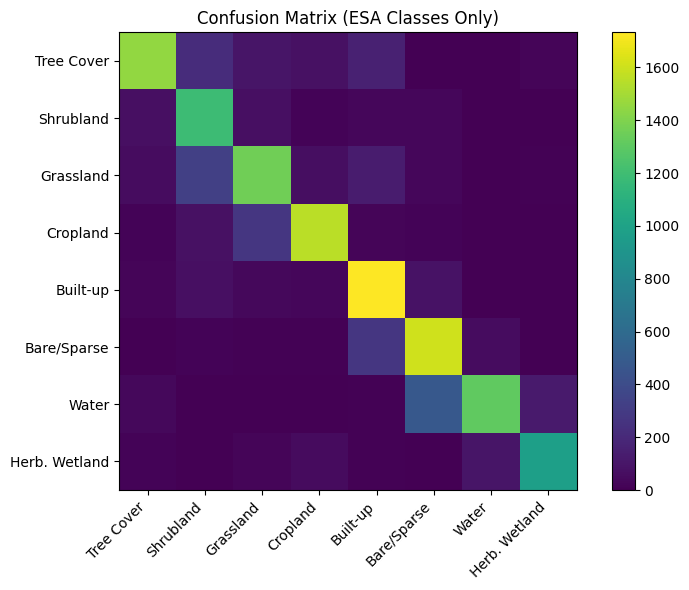

In [ ]:
full_cm = np.array(cm)
order = [int(x) for x in conf_matrix.order().getInfo()]

# Convert order values to int if needed
order = [int(x) for x in order]

# ESA classes used in training/validation
esa_classes = [10, 20, 30, 40, 50, 60, 80, 90]

esa_labels = {
    10: "Tree Cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/Sparse",
    80: "Water",
    90: "Herb. Wetland"
}

# 1️⃣ Indices of ESA classes in the full matrix
indices = [order.index(c) for c in esa_classes]

# 2️⃣ Extract the clean confusion matrix
clean_cm = full_cm[np.ix_(indices, indices)]

# 3️⃣ Build a DataFrame
df_cm = pd.DataFrame(
    clean_cm,
    index=[f"{c} - {esa_labels[c]}" for c in esa_classes],
    columns=[f"{c} - {esa_labels[c]}" for c in esa_classes]
)

print("\nClean ESA Confusion Matrix:")
print(df_cm)

In [71]:
from sklearn.metrics import classification_report

# clean_cm is the ESA-only confusion matrix   (shape = Nclasses × Nclasses)
# esa_classes = [10,20,30,40,50,60,80,90]

y_true = []
y_pred = []

# Reconstruct labels from the confusion matrix
for i, true_class in enumerate(esa_classes):
    for j, pred_class in enumerate(esa_classes):
        count = clean_cm[i, j]
        if count > 0:
            y_true.extend([true_class] * count)
            y_pred.extend([pred_class] * count)

# Human-readable labels
target_names = [esa_labels[c] for c in esa_classes]

# Generate classification report
report = classification_report(
    y_true, y_pred,
    labels=esa_classes,
    target_names=target_names,
    zero_division=0
)

print("\n=== Classification Report ===")
print(report)


=== Classification Report ===
               precision    recall  f1-score   support

   Tree Cover       0.86      0.71      0.78      2038
    Shrubland       0.62      0.85      0.72      1402
    Grassland       0.72      0.69      0.70      1973
     Cropland       0.86      0.79      0.82      1970
     Built-up       0.73      0.87      0.80      1988
  Bare/Sparse       0.71      0.81      0.76      1985
        Water       0.89      0.67      0.76      1965
Herb. Wetland       0.85      0.82      0.84      1192

     accuracy                           0.77     14513
    macro avg       0.78      0.78      0.77     14513
 weighted avg       0.78      0.77      0.77     14513



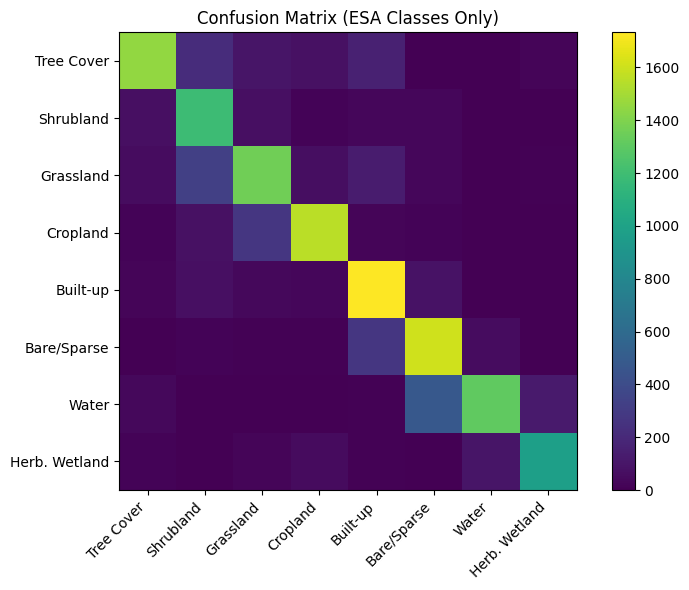

In [72]:
# 4️⃣ Optional: Plot nicely
plt.figure(figsize=(8,6))
plt.imshow(clean_cm)
plt.xticks(range(len(esa_classes)), [esa_labels[c] for c in esa_classes], rotation=45, ha='right')
plt.yticks(range(len(esa_classes)), [esa_labels[c] for c in esa_classes])
plt.colorbar()
plt.title("Confusion Matrix (ESA Classes Only)")
plt.tight_layout()
plt.show()

# Classify embeddings for multiple year

The classification result is going to be exported to your drive

In [ ]:
# -------------------------------
# 6️⃣ Classify embeddings for multiple years
# -------------------------------
years = [2021, 2022, 2023]

for year in years:
    print(f"Processing year {year}...")

    # Load embeddings for the year
    embeddings_img = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL') \
        .filterDate(f'{year}-01-01', f'{year+1}-01-01') \
        .filterBounds(roi) \
        .mosaic().clip(roi)
    
    # Classify using RF trained on 2021
    lulc = embeddings_img.classify(rf_classifier)

    # Export to Google Drive
    task = ee.batch.Export.image.toDrive(
        image=lulc,
        description=f'LULC_{year}',
        folder=output_drive_folder,
        fileNamePrefix=f'lulc_{year}',
        region=roi,
        scale=scale,
        maxPixels=1e13
    )
    task.start()
    print(f"Export started for LULC_{year}")

# you can check your tasks here: https://code.earthengine.google.com/tasks

Processing year 2021...
Export started for LULC_2021
Processing year 2022...
Export started for LULC_2022
Processing year 2023...
Export started for LULC_2023


# Analyze multiple years

In [ ]:
# Paths to your 3 LULC GeoTIFFs
import os
import rasterio

# you need to download the generated maps from your drive
base_path = "data/GEE_exports"

tif_files = {
    2021: os.path.join(base_path ,"lulc_2021.tif"),
    2022: os.path.join(base_path ,"lulc_2022.tif"),
    2023: os.path.join(base_path ,"lulc_2023.tif")
}

# ESA classes used
esa_classes = [10, 20, 30, 40, 50, 60, 80, 90]

# Optional: friendly names
esa_labels = {
    10: "Tree Cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/Sparse",
    80: "Water",
    90: "Herbaceous Wetland"
}

# Dictionary to store results
pixel_counts = {}

for year, path in tif_files.items():
    with rasterio.open(path) as src:
        data = src.read(1)  # Read the first band
        counts = {}
        for cls in esa_classes:
            counts[cls] = np.sum(data == cls)
        pixel_counts[year] = counts

# Convert to pandas DataFrame for easier viewing
df_counts = pd.DataFrame(pixel_counts).T  # years as rows
df_counts.rename(columns=esa_labels, inplace=True)

print(df_counts)

      Tree Cover  Shrubland  Grassland  Cropland  Built-up  Bare/Sparse  \
2021    46710937   10792169   22104973  37239326  15973026      2288393   
2022    45079136   16625468   17712901  37441519  16594081      1928109   
2023    46147986   14356920   19301416  37897764  15688032      1874967   

        Water  Herbaceous Wetland  
2021  3932636              392234  
2022  3691454              361026  
2023  3759344              407265  


In [ ]:
# Compute total pixels per year
total_pixels = df_counts.sum(axis=1)

# Convert to percentage
df_percent = df_counts.divide(total_pixels, axis=0) * 100
df_percent = df_percent.round(2)

print("LULC percentage per year (%):")
print(df_percent)

LULC percentage per year (%):
      Tree Cover  Shrubland  Grassland  Cropland  Built-up  Bare/Sparse  \
2021       33.50       7.74      15.85     26.71     11.46         1.64   
2022       32.33      11.92      12.70     26.85     11.90         1.38   
2023       33.10      10.30      13.84     27.18     11.25         1.34   

      Water  Herbaceous Wetland  
2021   2.82                0.28  
2022   2.65                0.26  
2023   2.70                0.29  


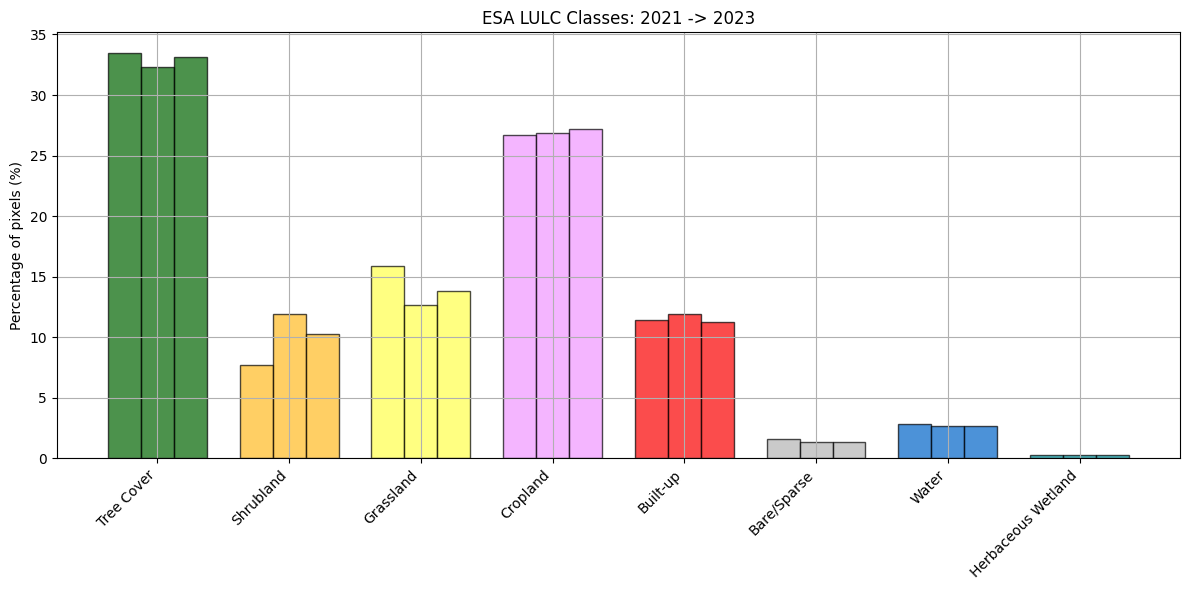

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

classes = ["Tree Cover", "Shrubland", "Grassland", "Cropland",
           "Built-up", "Bare/Sparse", "Water", "Herbaceous Wetland"]
years = df_percent.index.tolist()  # [2021, 2022, 2023]

# ESA colors
esa_colors = ["#006400", "#FFBB22", "#FFFF4C", "#F096FF",
              "#FA0000", "#B4B4B4", "#0064C8", "#0096A0"]

x = np.arange(len(classes))  # positions of groups
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(12,6))

# Plot bars for each year with transparency and black contour
for i, year in enumerate(years):
    ax.bar(x + i*width - width, df_percent.loc[year, classes],
           width=width, 
           color=esa_colors, 
           edgecolor='black', 
           alpha=0.7, 
           label=str(year))

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')

ax.set_ylabel("Percentage of pixels (%)")
ax.set_title("ESA LULC Classes: 2021 -> 2023")

plt.tight_layout()
plt.grid()
plt.show()

# Off line map plot

In [95]:
from matplotlib.colors import ListedColormap

esa_classes = [10, 20, 30, 40, 50, 60, 80, 90]
esa_labels = ["Tree Cover", "Shrubland", "Grassland", "Cropland",
              "Built-up", "Bare/Sparse", "Water", "Herbaceous Wetland"]
esa_colors = ["#006400", "#FFBB22", "#FFFF4C", "#F096FF",
              "#FA0000", "#B4B4B4", "#0064C8", "#0096A0"]

# Create colormap
cmap = ListedColormap(esa_colors)


In [ ]:

def plot_lulc_map_safe(tif_path, title, save_path=None):
    with rasterio.open(tif_path) as src:
        data = src.read(1)
    
    # Create an array of same shape with -1 for invalid pixels
    color_indices = np.full_like(data, fill_value=-1, dtype=int)
    
    # Map each ESA class to its colormap index
    for idx, cls in enumerate(esa_classes):
        color_indices[data == cls] = idx

    # Set unmapped pixels to NaN so they appear transparent
    color_indices = np.where(color_indices==-1, np.nan, color_indices)

    plt.figure(figsize=(8,8))
    plt.imshow(color_indices, cmap=cmap, interpolation='none')
    plt.title(title)
    plt.axis('off')
    
    # Legend
    legend_patches = [Patch(color=esa_colors[i], label=esa_labels[i])
                      for i in range(len(esa_classes))]
    plt.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

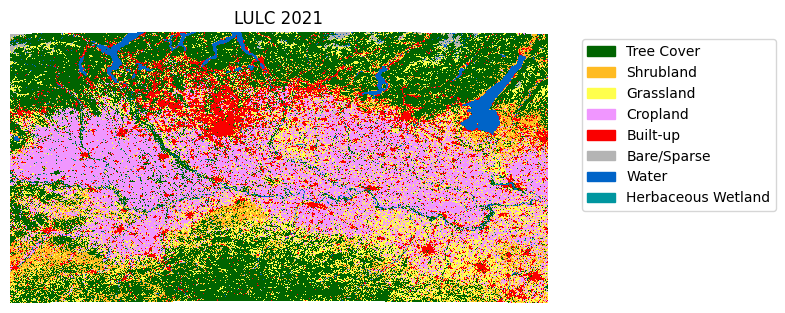

In [101]:
plot_lulc_map_safe(os.path.join(base_path ,"lulc_2021.tif"), "LULC 2021", save_path=os.path.join(base_path ,"lulc_2021.png"))

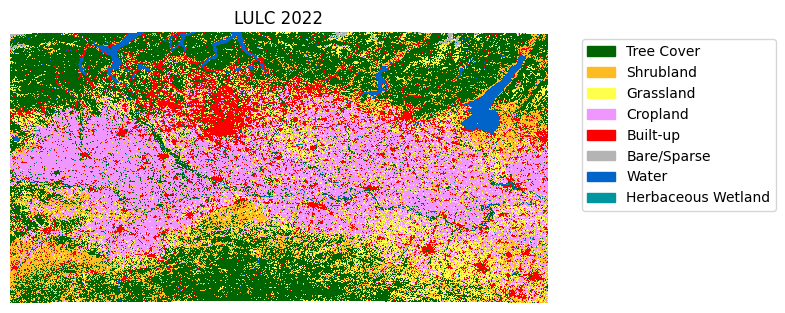

In [102]:
plot_lulc_map_safe(os.path.join(base_path ,"lulc_2022.tif"), "LULC 2022", save_path=os.path.join(base_path ,"lulc_2022.png"))

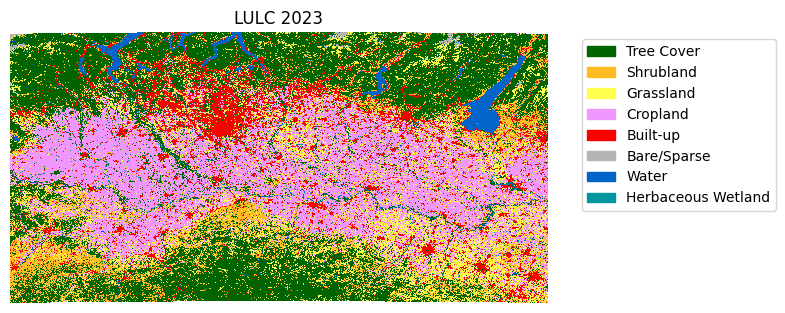

In [103]:
plot_lulc_map_safe(os.path.join(base_path ,"lulc_2023.tif"), "LULC 2023", save_path=os.path.join(base_path ,"lulc_2023.png"))

In [104]:
def compute_change_raster(tif_year1, tif_year2, save_path=None):
    """
    Compute a binary raster: 0 = no change, 1 = change
    """
    with rasterio.open(tif_year1) as src1:
        data1 = src1.read(1)
        meta = src1.meta.copy()  # keep metadata to save output

    with rasterio.open(tif_year2) as src2:
        data2 = src2.read(1)

    # Binary change: 1 if values differ, 0 if same
    change = (data1 != data2).astype(np.uint8)

    # Save raster if requested
    if save_path:
        meta.update(dtype=rasterio.uint8, count=1)
        with rasterio.open(save_path, 'w', **meta) as dst:
            dst.write(change, 1)

    return change

In [ ]:
change_21_22 = compute_change_raster(
    os.path.join(base_path ,"lulc_2021.tif"), os.path.join(base_path ,"lulc_2022.tif"), save_path=os.path.join(base_path ,"change_2021_2022.tif")
)

change_22_23 = compute_change_raster(
    os.path.join(base_path ,"lulc_2022.tif"), os.path.join(base_path ,"lulc_2023.tif"), save_path=os.path.join(base_path ,"change_2022_2023.tif")
)

In [115]:
# generate gif from maps

from PIL import Image

# Paths to your PNG maps
png_files = [os.path.join(base_path ,"lulc_2021.png"), os.path.join(base_path ,"lulc_2022.png"), os.path.join(base_path ,"lulc_2023.png")]

# Open images
images = [Image.open(f) for f in png_files]

# Save as GIF
images[0].save(
    os.path.join(base_path, "lulc_change.gif"),
    save_all=True,
    append_images=images[1:],
    duration=1000,   # duration of each frame in milliseconds
    loop=0           # 0 = infinite loop
)
